# Bayesian Neural Network with Laplace Approximation

This notebook demonstrates Bayesian inference on neural networks using Laplace approximation. We'll train a neural network on sinusoidal regression data and use Laplace approximation to quantify uncertainty in predictions.

## 1. Import Required Libraries

In [9]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Patch

from laplace import Laplace, marglik_training
from laplace.curvature.backpack import BackPackGGN

try:
    from helper.dataloaders import get_sinusoid_example
    from helper.util import plot_regression
    HELPERS_AVAILABLE = True
except ImportError:
    print("Warning: helper modules not available. Will define alternatives.")
    HELPERS_AVAILABLE = False

np.random.seed(711)
torch.manual_seed(711)




## 2. Set Up Data and Configuration

In [10]:
# Configuration
n_epochs = 1000
batch_size = 32
sigma_noise = 0.3

# Generate or load data
if HELPERS_AVAILABLE:
    X_train, y_train, train_loader, X_test = get_sinusoid_example(sigma_noise=sigma_noise)
else:
    # Fallback: create sinusoid data manually
    n_train = 100
    X_train = torch.linspace(-3, 3, n_train).unsqueeze(1)
    y_train = torch.sin(X_train) + sigma_noise * torch.randn_like(X_train)
    train_loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(X_train, y_train),
        batch_size=batch_size,
        shuffle=True
    )
    X_test = torch.linspace(-4, 4, 200).unsqueeze(1)

print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")
print(f"Number of training batches: {len(train_loader)}")




Training data shape: torch.Size([150, 1])
Test data shape: torch.Size([500, 1])
Number of training batches: 1


## 3. Implement Core Code: MAP Training and Laplace Approximation

We'll train a neural network using MAP (Maximum A Posteriori) estimation, then fit a Laplace approximation to quantify uncertainty.

In [11]:
# Define model architecture
def get_model():
    torch.manual_seed(711)
    return torch.nn.Sequential(
        torch.nn.Linear(1, 50), 
        torch.nn.Tanh(), 
        torch.nn.Linear(50, 1)
    )

# Train MAP (Maximum A Posteriori)
print("Training MAP model...")
model = get_model()
criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)

train_losses = []
for i in range(n_epochs):
    epoch_loss = 0.0
    for X, y in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(X), y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    epoch_loss /= len(train_loader)
    train_losses.append(epoch_loss)
    
    if (i + 1) % 200 == 0:
        print(f"Epoch {i+1}/{n_epochs}, Loss: {epoch_loss:.4f}")

print("MAP training complete!")




Training MAP model...
Epoch 200/1000, Loss: 0.0782
Epoch 400/1000, Loss: 0.0757
Epoch 600/1000, Loss: 0.0750
Epoch 800/1000, Loss: 0.0752
Epoch 1000/1000, Loss: 0.0741
MAP training complete!


In [12]:
# Fit Laplace approximation
print("Fitting Laplace approximation...")
la = Laplace(model, "regression", subset_of_weights="all", hessian_structure="full")
la.fit(train_loader)

# Optimize hyperparameters using marginal likelihood
print("Optimizing hyperparameters...")
log_prior = torch.ones(1, requires_grad=True)
log_sigma = torch.ones(1, requires_grad=True)
hyper_optimizer = torch.optim.Adam([log_prior, log_sigma], lr=1e-1)

marglik_values = []
for i in range(n_epochs):
    hyper_optimizer.zero_grad()
    neg_marglik = -la.log_marginal_likelihood(log_prior.exp(), log_sigma.exp())
    neg_marglik.backward()
    hyper_optimizer.step()
    marglik_values.append(-neg_marglik.item())
    
    if (i + 1) % 200 == 0:
        print(f"Epoch {i+1}/{n_epochs}, Marginal Likelihood: {-neg_marglik.item():.4f}")

print("Laplace approximation complete!")
print(f"Learned sigma_noise: {la.sigma_noise.item():.4f}")
print(f"Learned prior precision: {la.prior_precision.item():.4f}")




Fitting Laplace approximation...
Optimizing hyperparameters...
Epoch 200/1000, Marginal Likelihood: -59.0499
Epoch 400/1000, Marginal Likelihood: -59.0493
Epoch 600/1000, Marginal Likelihood: -59.0831
Epoch 800/1000, Marginal Likelihood: -59.0665
Epoch 1000/1000, Marginal Likelihood: -59.0743
Laplace approximation complete!
Learned sigma_noise: 0.2819
Learned prior precision: 0.1008


## 4. Run Code and Generate Predictions

Now we'll generate predictions with uncertainty estimates on the test data.

In [13]:
# Generate predictions
print("Generating predictions...")

# Marginal predictive distribution: N(f_map(x_i), var(x_i))
f_mu, f_var = la(X_test)

# Joint predictive distribution: N(f_map, Cov(f))
f_mu_joint, f_cov = la(X_test, joint=True)

# Convert to numpy
x_test_np = X_test.flatten().cpu().numpy()
f_mu_np = f_mu.squeeze().detach().cpu().numpy()
f_var_np = f_var.squeeze().detach().cpu().numpy()
f_sigma_np = np.sqrt(f_var_np)

# Total predictive uncertainty (aleatoric + epistemic)
pred_std = np.sqrt(f_sigma_np**2 + la.sigma_noise.item() ** 2)

# Verify marginal and joint predictions match
assert torch.allclose(f_mu.flatten(), f_mu_joint)
assert torch.allclose(f_var.flatten(), f_cov.diag())
print("✓ Marginal and joint predictions verified!")

# Convert training data to numpy for visualization
X_train_np = X_train.flatten().cpu().numpy()
y_train_np = y_train.flatten().cpu().numpy()

print(f"Test predictions shape: {f_mu_np.shape}")
print(f"Epistemic uncertainty (std): {f_sigma_np.mean():.4f}")
print(f"Aleatoric uncertainty (noise std): {la.sigma_noise.item():.4f}")




Generating predictions...
✓ Marginal and joint predictions verified!
Test predictions shape: (500,)
Epistemic uncertainty (std): 1.7009
Aleatoric uncertainty (noise std): 0.2819


## 5. Visualize Results

We'll create comprehensive visualizations showing predictions, uncertainty, and training progress.

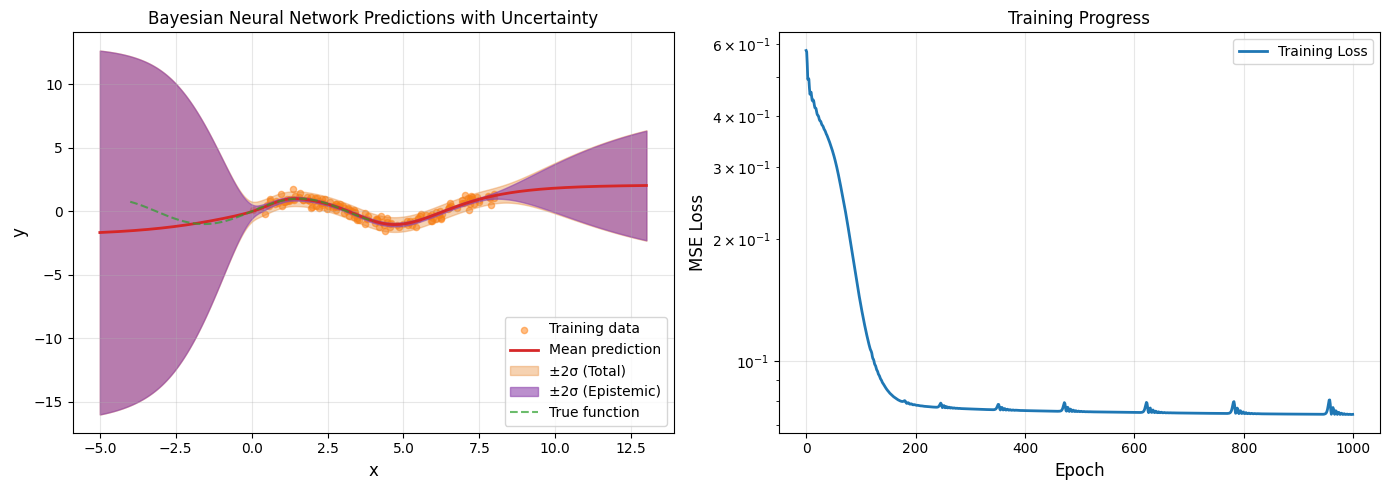

Regression plot completed!


In [14]:
# Main regression plot with uncertainty
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Regression with uncertainty bands
ax = axes[0]
ax.scatter(X_train_np, y_train_np, color='#ff7f0e', s=20, alpha=0.5, label='Training data')
ax.plot(x_test_np, f_mu_np, color='#d62728', linewidth=2, label='Mean prediction')
ax.fill_between(x_test_np, 
                 f_mu_np - 2*pred_std, 
                 f_mu_np + 2*pred_std, 
                 alpha=0.35, color='#e67e22', label='±2σ (Total)')
ax.fill_between(x_test_np, 
                 f_mu_np - 2*f_sigma_np, 
                 f_mu_np + 2*f_sigma_np, 
                 alpha=0.6, color='#8e44ad', label='±2σ (Epistemic)')

# Plot true function if available
x_dense = np.linspace(-4, 4, 500)
y_true = np.sin(x_dense)
ax.plot(x_dense, y_true, color='#2ca02c', linestyle='--', linewidth=1.5, alpha=0.7, label='True function')

ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('y', fontsize=12)
ax.set_title('Bayesian Neural Network Predictions with Uncertainty', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Plot 2: Training loss
ax = axes[1]
ax.plot(train_losses, linewidth=2, label='Training Loss')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('MSE Loss', fontsize=12)
ax.set_title('Training Progress', fontsize=12)
ax.set_yscale('log')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

print("Regression plot completed!")




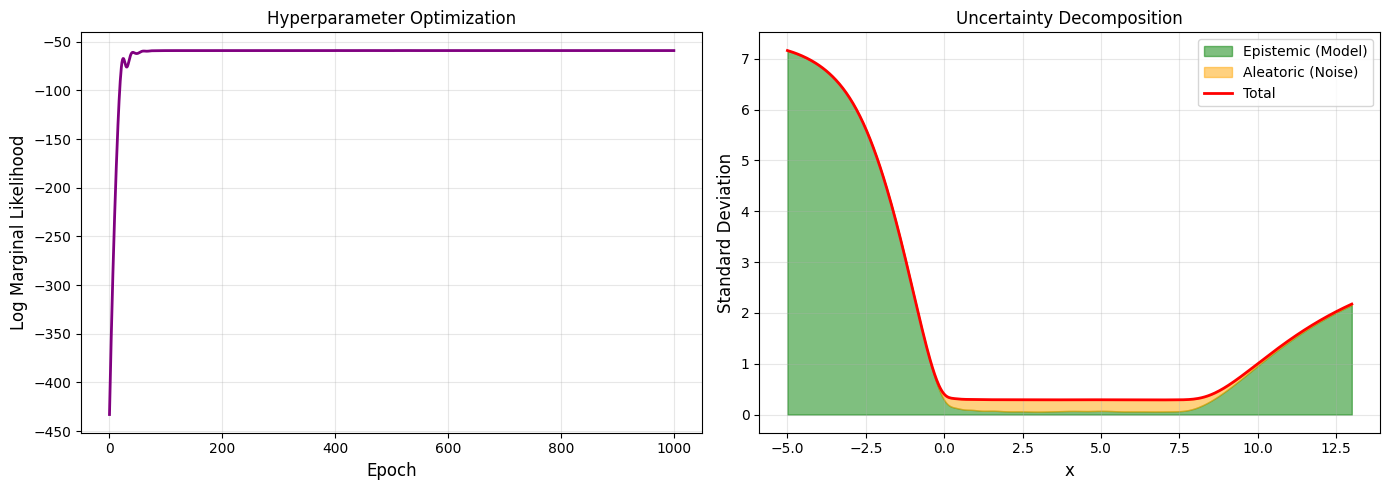

Hyperparameter and uncertainty plots completed!


In [15]:
# Hyperparameter optimization visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot marginal likelihood
ax = axes[0]
ax.plot(marglik_values, linewidth=2, color='purple')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Log Marginal Likelihood', fontsize=12)
ax.set_title('Hyperparameter Optimization', fontsize=12)
ax.grid(True, alpha=0.3)

# Plot uncertainty decomposition
ax = axes[1]
epistemic = f_sigma_np
aleatoric = np.full_like(f_sigma_np, la.sigma_noise.item())
total = pred_std

ax.fill_between(x_test_np, 0, epistemic, alpha=0.5, label='Epistemic (Model)', color='green')
ax.fill_between(x_test_np, epistemic, total, alpha=0.5, label='Aleatoric (Noise)', color='orange')
ax.plot(x_test_np, total, 'r-', linewidth=2, label='Total')
ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('Standard Deviation', fontsize=12)
ax.set_title('Uncertainty Decomposition', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Hyperparameter and uncertainty plots completed!")




## 6. Compare Multiple Runs with Different Parameters

Let's compare predictions with different noise levels and network architectures.

In [16]:
# Parametric study: compare different noise levels
print("Running parametric study with different noise levels...")
noise_levels = [0.1, 0.3, 0.5]
results = {}

for noise_level in noise_levels:
    print(f"  Training with noise level {noise_level}...")
    torch.manual_seed(711)
    
    # Generate data
    n_train = 100
    X_train_param = torch.linspace(-3, 3, n_train).unsqueeze(1)
    y_train_param = torch.sin(X_train_param) + noise_level * torch.randn_like(X_train_param)
    train_loader_param = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(X_train_param, y_train_param),
        batch_size=batch_size,
        shuffle=True
    )
    
    # Train model
    model_param = get_model()
    optimizer_param = torch.optim.Adam(model_param.parameters(), lr=1e-2)
    for _ in range(500):  # Shorter training for comparison
        for X, y in train_loader_param:
            optimizer_param.zero_grad()
            loss = criterion(model_param(X), y)
            loss.backward()
            optimizer_param.step()
    
    # Fit Laplace
    la_param = Laplace(model_param, "regression", subset_of_weights="all", hessian_structure="full")
    la_param.fit(train_loader_param)
    
    # Optimize hyperparameters via marginal likelihood
    log_prior_p = torch.ones(1, requires_grad=True)
    log_sigma_p = torch.ones(1, requires_grad=True)
    hyper_opt_p = torch.optim.Adam([log_prior_p, log_sigma_p], lr=1e-1)
    for _ in range(500):
        hyper_opt_p.zero_grad()
        neg_marglik = -la_param.log_marginal_likelihood(log_prior_p.exp(), log_sigma_p.exp())
        neg_marglik.backward()
        hyper_opt_p.step()
    
    # Predictions
    f_mu_param, f_var_param = la_param(X_test)
    f_sigma_param = np.sqrt(f_var_param.squeeze().detach().cpu().numpy())
    pred_std_param = np.sqrt(f_sigma_param**2 + log_sigma_p.exp().item()**2)
    
    results[noise_level] = {
        'f_mu': f_mu_param.squeeze().detach().cpu().numpy(),
        'pred_std': pred_std_param,
        'sigma_noise': log_sigma_p.exp().item()
    }

print("Parametric study complete!")


Running parametric study with different noise levels...
  Training with noise level 0.1...
  Training with noise level 0.3...
  Training with noise level 0.5...
Parametric study complete!


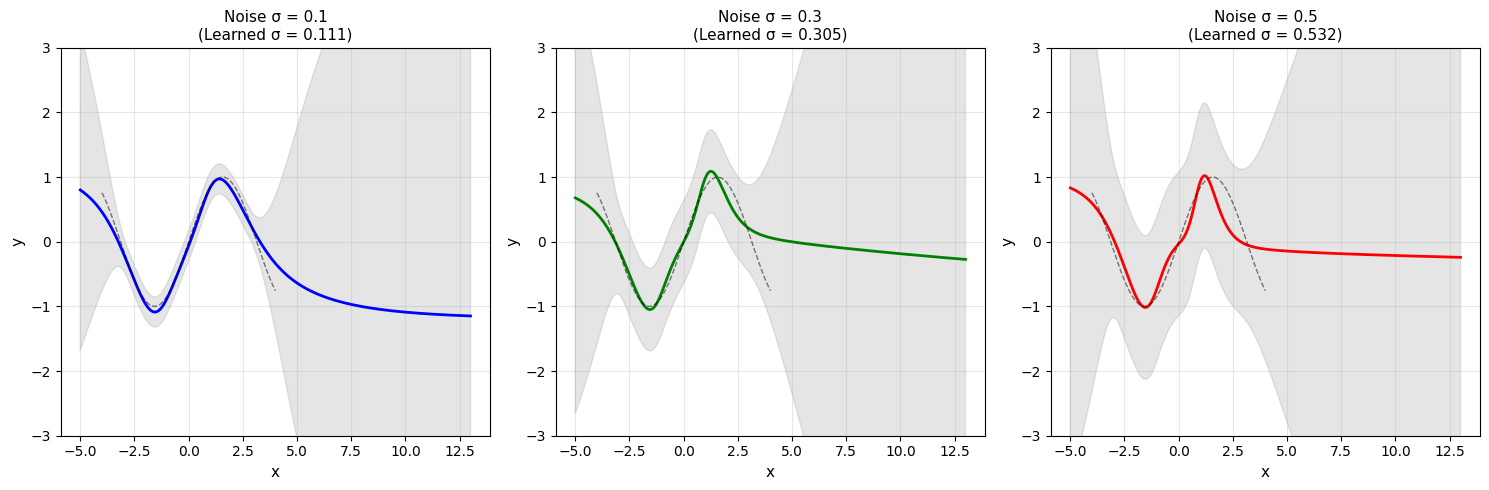

Parametric comparison plots completed!


In [17]:
# Visualization of parametric study
fig, axes = plt.subplots(1, len(noise_levels), figsize=(15, 5))

colors = ['blue', 'green', 'red']
for idx, noise_level in enumerate(noise_levels):
    ax = axes[idx]
    result = results[noise_level]
    
    ax.plot(x_test_np, result['f_mu'], color=colors[idx], linewidth=2, label='Mean')
    ax.fill_between(x_test_np, 
                     result['f_mu'] - 2*result['pred_std'], 
                     result['f_mu'] + 2*result['pred_std'], 
                     alpha=0.2, color='gray')
    
    # True function
    ax.plot(x_dense, y_true, 'k--', linewidth=1, alpha=0.5)
    
    ax.set_xlabel('x', fontsize=11)
    ax.set_ylabel('y', fontsize=11)
    ax.set_title(f'Noise σ = {noise_level}\n(Learned σ = {result["sigma_noise"]:.3f})', fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-3, 3)

plt.tight_layout()
plt.show()

print("Parametric comparison plots completed!")




## 7. Save and Export Results

Save trained models, predictions, and visualizations for future use.

In [18]:
# Save trained model and Laplace state
print("Saving results...")

# Create output directory
import os
output_dir = "./bnn_results"
os.makedirs(output_dir, exist_ok=True)

# Save model state dict
state_dict = la.state_dict()
torch.save(state_dict, os.path.join(output_dir, "laplace_state_dict.bin"))

# Save predictions
predictions = {
    'x_test': x_test_np,
    'f_mu': f_mu_np,
    'f_sigma': f_sigma_np,
    'pred_std': pred_std,
    'X_train': X_train_np,
    'y_train': y_train_np
}
np.save(os.path.join(output_dir, "predictions.npy"), predictions, allow_pickle=True)

# Save summary statistics
summary = {
    'learned_sigma_noise': la.sigma_noise.item(),
    'learned_prior_precision': la.prior_precision.item(),
    'final_training_loss': train_losses[-1],
    'final_marginal_likelihood': marglik_values[-1]
}

import json
with open(os.path.join(output_dir, "summary.json"), 'w') as f:
    json.dump(summary, f, indent=2)

print(f"✓ Results saved to '{output_dir}' directory")
print(f"  - laplace_state_dict.bin: Trained Laplace model")
print(f"  - predictions.npy: Test predictions and uncertainties")
print(f"  - summary.json: Summary statistics")

# Print final summary
print("\n" + "="*50)
print("TRAINING SUMMARY")
print("="*50)
print(f"Training Loss (final): {train_losses[-1]:.6f}")
print(f"Marginal Likelihood (final): {marglik_values[-1]:.4f}")
print(f"Learned Noise Std: {la.sigma_noise.item():.4f}")
print(f"Learned Prior Precision: {la.prior_precision.item():.4f}")
print(f"Mean Epistemic Uncertainty: {f_sigma_np.mean():.4f}")
print(f"Mean Total Uncertainty: {pred_std.mean():.4f}")
print("="*50)




Saving results...
✓ Results saved to './bnn_results' directory
  - laplace_state_dict.bin: Trained Laplace model
  - predictions.npy: Test predictions and uncertainties
  - summary.json: Summary statistics

TRAINING SUMMARY
Training Loss (final): 0.074138
Marginal Likelihood (final): -59.0743
Learned Noise Std: 0.2819
Learned Prior Precision: 0.1008
Mean Epistemic Uncertainty: 1.7009
Mean Total Uncertainty: 1.8161
